In [1]:
import pandas as pd


In [55]:
df=pd.read_csv("study_data(1).csv")
df

FileNotFoundError: [Errno 2] No such file or directory: 'study_data(1).csv'

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               30 non-null     object 
 1   Total_study_hours  21 non-null     float64
 2   Max_focus_hours    21 non-null     float64
 3   Start time         21 non-null     object 
 4   End time           21 non-null     object 
 5   Subject            21 non-null     object 
 6   Day off            29 non-null     object 
 7   Start_hour         21 non-null     float64
dtypes: float64(3), object(5)
memory usage: 2.0+ KB


In [4]:
df.isnull().sum()

Date                 0
Total_study_hours    9
Max_focus_hours      9
Start time           9
End time             9
Subject              9
Day off              1
dtype: int64

In [8]:
df.describe()

,Total_study_hours,Max_focus_hours
count,21.000000,21.000000
mean,6.952381,4.138095
std,3.032758,2.087696
min,1.000000,1.000000
25%,5.000000,3.000000
50%,6.000000,3.500000
75%,9.000000,4.500000
max,12.500000,10.000000


In [9]:
df["Day off"].value_counts(dropna=False)

Day off
No     21
Yes     8
NaN     1
Name: count, dtype: int64

In [10]:
df.isnull().sum()

Date                 0
Total_study_hours    9
Max_focus_hours      9
Start time           9
End time             9
Subject              9
Day off              1
dtype: int64

In [21]:
df.head()

,Date,Total_study_hours,Max_focus_hours,Start time,End time,Subject,Day off
0,9/1/2026,NaN,NaN,NaN,NaN,NaN,Yes
1,9/2/2026,NaN,NaN,NaN,NaN,NaN,Yes
2,9/3/2026,6.0,3.5,12PM,10PM,Python,No
3,9/4/2026,10.0,4.5,1PM,5AM,Python,No
4,9/5/2026,6.5,2.0,7AM,5PM,Python,No


In [22]:
df.tail()

,Date,Total_study_hours,Max_focus_hours,Start time,End time,Subject,Day off
25,9/26/2026,NaN,NaN,NaN,NaN,NaN,Yes
26,9/27/2026,NaN,NaN,NaN,NaN,NaN,Yes
27,9/28/2026,NaN,NaN,NaN,NaN,NaN,Yes
28,9/29/2026,NaN,NaN,NaN,NaN,NaN,Yes
29,9/30/2026,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df().fillna(df['age'

In [11]:
import matplotlib.pyplot as plt

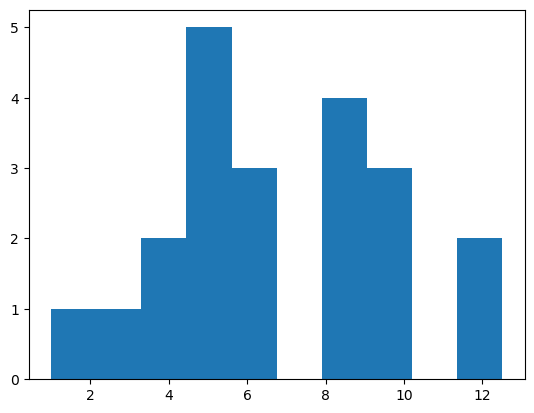

In [14]:
plt.hist(df["Total_study_hours"])
plt.show()

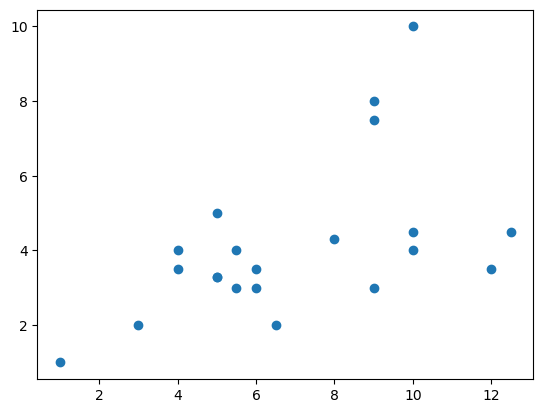

In [20]:
plt.scatter(x="Total_study_hours",
            y="Max_focus_hours",data=df)
plt.show()

In [29]:
df['Start_hour']=pd.to_datetime(
    df['Start time'],
    format='%I%p',
    errors='corcoe'
).dt.hour

AssertionError: 

In [31]:
#NaN values are kept because no study time was recorded on those days

df['Start_hour'] = df['Start time'].str.extract(r'(\d+)')[0].astype(float)

df.loc[df['Start time'].str.contains('PM', na=False) & 
       (df['Start_hour'] != 12), 'Start_hour'] += 12


In [34]:
df[['Start time',
'Start_hour']].dropna()

,Start time,Start_hour
2,12PM,12.0
3,1PM,13.0
4,7AM,7.0
6,9AM,9.0
7,2PM,14.0
8,2PM,14.0
9,4PM,16.0
10,10AM,10.0
11,2PM,14.0
12,11AM,11.0


In [39]:
import seaborn as sns

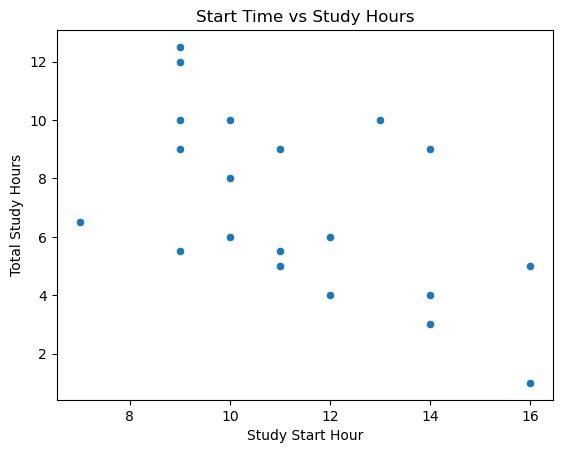

In [40]:
#Start Time vs Study Hours

sns.scatterplot(
    data=df.dropna(subset=['Start_hour', 'Total_study_hours']),
    x='Start_hour',
    y='Total_study_hours'
)

plt.title('Start Time vs Study Hours')
plt.xlabel('Study Start Hour')
plt.ylabel('Total Study Hours')

plt.show()


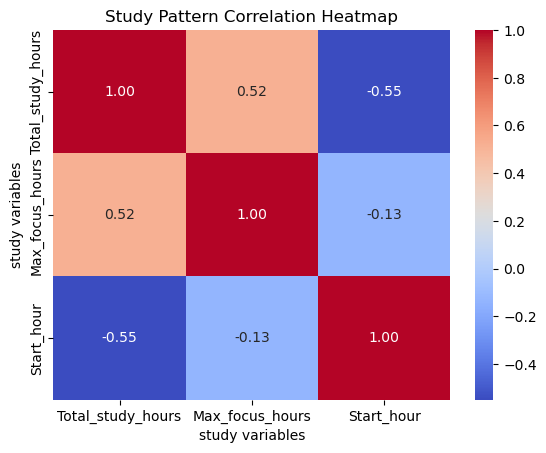

In [42]:
#Correlation Heatmap

corr = df[['Total_study_hours', 'Max_focus_hours', 'Start_hour']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Study Pattern Correlation Heatmap')
plt.xlabel('study variables')
plt.ylabel('study variables')

plt.show()


In [43]:
 df[['Total_study_hours', 'Max_focus_hours']].describe()

,Total_study_hours,Max_focus_hours
count,21.000000,21.000000
mean,6.952381,4.138095
std,3.032758,2.087696
min,1.000000,1.000000
25%,5.000000,3.000000
50%,6.000000,3.500000
75%,9.000000,4.500000
max,12.500000,10.000000


In [46]:
subject_analysis = df.groupby('Subject')[['Total_study_hours', 'Max_focus_hours']].agg(
    ['mean', 'sum']
)
subject_analysis

Total_study_hours       Max_focus_hours      
                     mean   sum            mean   sum
Subject                                              
Pyhton          10.000000  10.0       10.000000  10.0
Python           6.428571  45.0        3.142857  22.0
Python           7.500000  37.5        4.300000  21.5
Stats            6.928571  48.5        4.057143  28.4
Stats            5.000000   5.0        5.000000   5.0

In [49]:
df['Subject']=df['Subject'].str.strip()

In [50]:
df['Subject'].unique()

array([nan, 'Python', 'Stats', 'Pyhton'], dtype=object)